In [20]:
!pip install matminer
!pip install pandas numpy mendeleev matminer
!pip install shap

In [9]:

from matminer.datasets import load_dataset
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from mendeleev import element
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xg
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np




In [10]:

df = load_dataset("steel_strength")
print(df.head())

                                             formula     c    mn    si     cr  \
0  Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...  0.02  0.05  0.05   0.01   
1  Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....  0.18  0.01  0.01  13.44   
2  Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....  0.00  0.01  0.01   8.67   
3  Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...  0.01  0.05  0.05   0.01   
4  Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...  0.01  0.05  0.05   0.01   

      ni    mo     v     n    nb     co     w    al    ti  yield strength  \
0  19.70  2.95  0.01  0.00  0.01  15.00  0.00  0.15  1.55          2411.5   
1   0.01  3.01  0.46  0.04  0.01  19.46  2.35  0.04  0.00          1123.1   
2  13.45  0.82  0.01  0.00  0.01  13.90  0.00  0.39  0.57          1736.3   
3  17.70  3.95  0.01  0.00  0.01  15.00  0.00  0.13  1.47          2487.3   
4  19.40  1.45  0.01  0.00  0.01  14.90  0.00  0.13  1.55          2249.6   

   tensile strength  elongation  
0            247

In [11]:
X = df.drop(columns=['formula', 'yield strength'])
y = df['yield strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [12]:
def get_alloy_features(composition_dict):


    avg_atomic_weight = 0
    avg_electronegativity = 0
    avg_atomic_radius = 0

    for symbol, fraction in composition_dict.items():
        el = element(symbol)
        avg_atomic_weight += el.atomic_weight * fraction
        avg_electronegativity += el.electronegativity() * fraction
        avg_atomic_radius += el.atomic_radius * fraction

    return {
        'Avg_Weight': avg_atomic_weight,
        'Avg_EN': avg_electronegativity,
        'Avg_Radius': avg_atomic_radius
    }

my_alloy = {'Fe': 0.45, 'Ni': 0.4}
features = get_alloy_features(my_alloy)
print(f"\n{features}")


{'Avg_Weight': 48.60761, 'Avg_EN': 1.5875, 'Avg_Radius': 117.0}


In [13]:
print(f"\n {len(df)}")


 312


In [14]:
X = df.drop(columns=['yield strength', 'formula'])
y = df['yield strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n---  Results ---")
print(f"  (R2 Score): {score:.2f}")
print(f"  (MAE): {mae:.2f} MPa")


---  Results ---
  (R2 Score): 0.93
  (MAE): 51.20 MPa


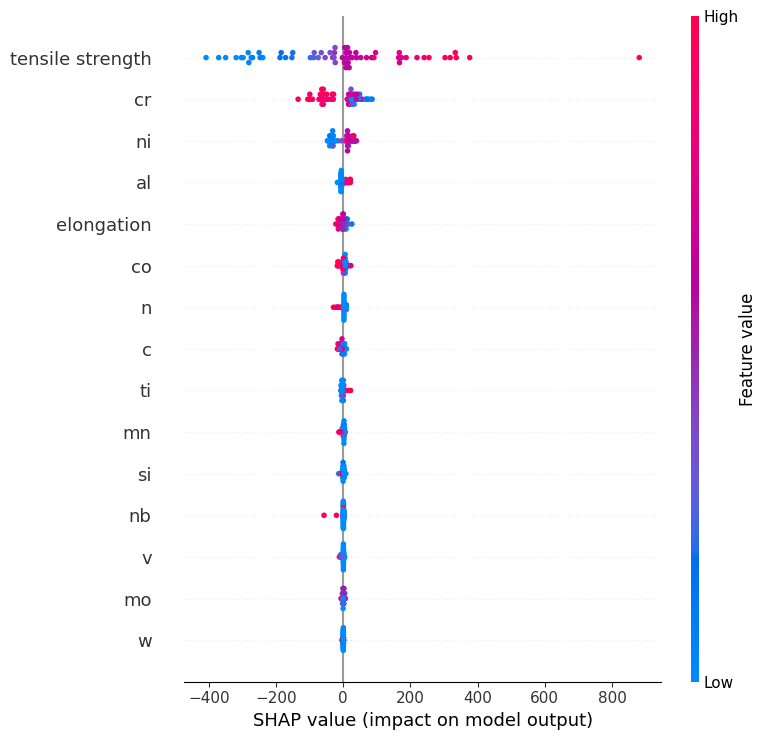

In [15]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [16]:
new_alloy_data = {
    'c': [0.0],
    'mn': [0.0],
    'si': [0.0],
    'cr': [18.5],
    'ni': [10.2],
    'mo': [0.0],
    'v': [0.0],
    'n': [0.0],
    'nb': [0.0],
    'co': [0.0],
    'w': [0.0],
    'al': [0.5],
    'ti': [0.0],
    'tensile strength': [650.0],
    'elongation': [15.0]
}

new_df = pd.DataFrame(new_alloy_data)

prediction = model.predict(new_df)

print(f" {prediction[0]:.2f} MPa")

 1098.58 MPa


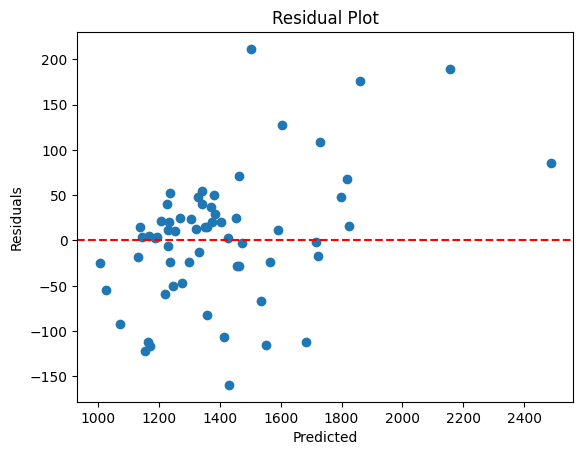

In [ ]:
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


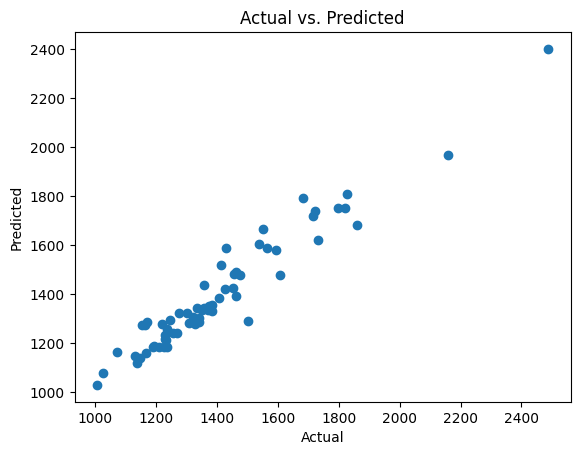

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

## XGBoost

In [17]:
xgb_model = xg.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print(f"R2 Score (XGBoost): {r2_score(y_test, y_pred_xgb):.3f}")
print(f"MAE (XGBoost): {mean_absolute_error(y_test, y_pred_xgb):.2f}")

R2 Score (XGBoost): 0.919
MAE (XGBoost): 51.78


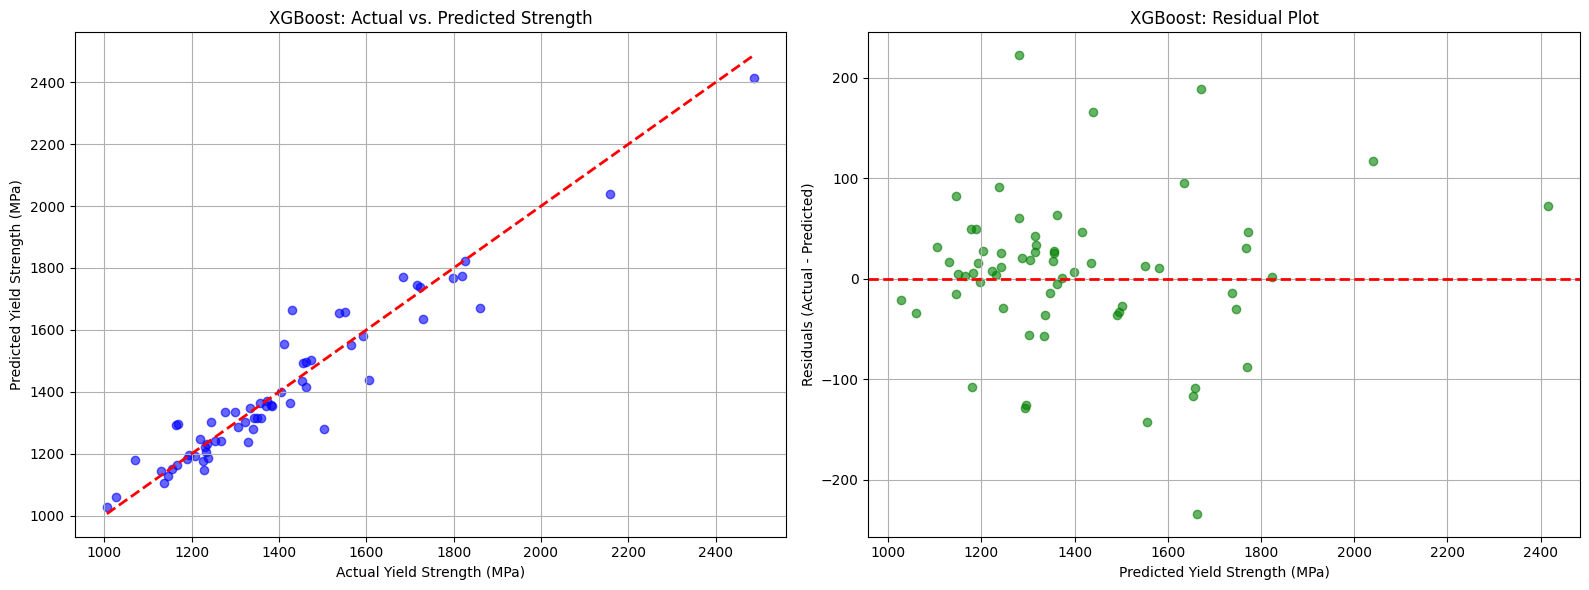

In [18]:
residuals_xgb = y_test - y_pred_xgb

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(y_test, y_pred_xgb, alpha=0.6, color='b')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # خط الـ ideal
ax[0].set_title('XGBoost: Actual vs. Predicted Strength')
ax[0].set_xlabel('Actual Yield Strength (MPa)')
ax[0].set_ylabel('Predicted Yield Strength (MPa)')
ax[0].grid(True)

ax[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.6, color='g')
ax[1].axhline(y=0, color='r', linestyle='--', lw=2) # خط الصفر
ax[1].set_title('XGBoost: Residual Plot')
ax[1].set_xlabel('Predicted Yield Strength (MPa)')
ax[1].set_ylabel('Residuals (Actual - Predicted)')
ax[1].grid(True)

plt.tight_layout()
plt.show()

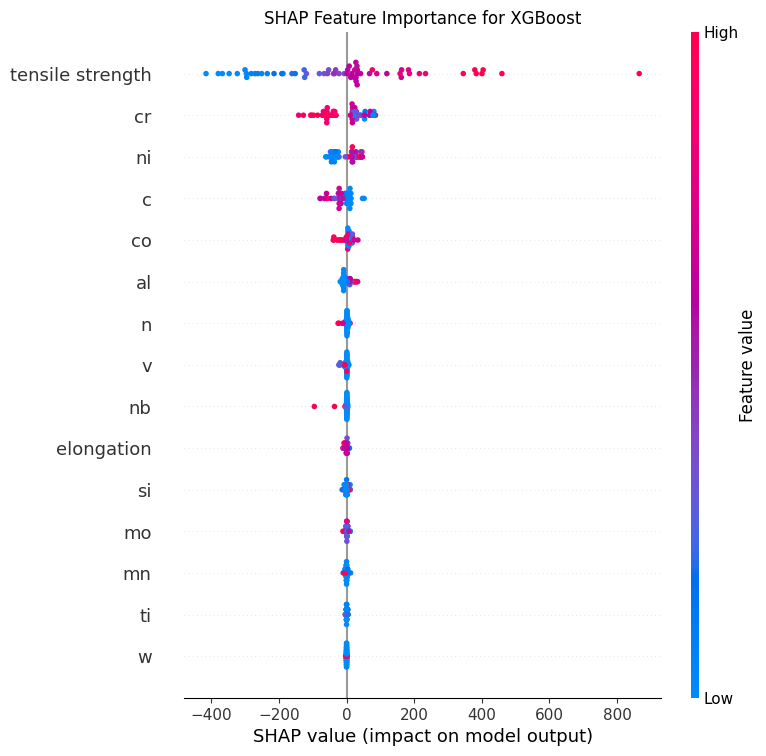

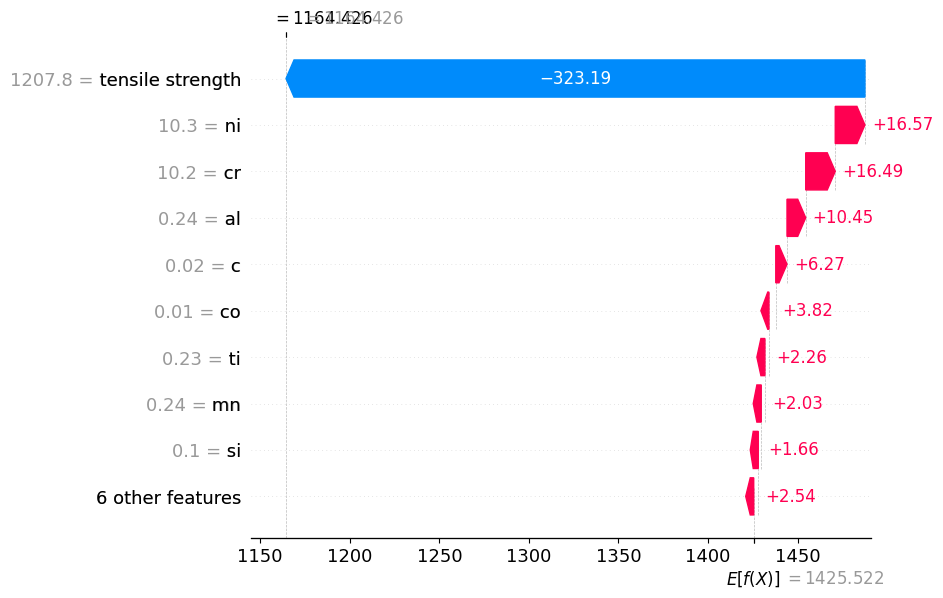

In [19]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance for XGBoost")
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(values=shap_values[0],
                                      base_values=explainer.expected_value,
                                      data=X_test.iloc[0],
                                      feature_names=X_test.columns.tolist()), show=False)
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

##**Optimization Script**

In [ ]:
cr_range = np.linspace(5, 20, 10)
ni_range = np.linspace(5, 10, 5)
c_range = np.linspace(0.1, 0.5, 5)

default_tensile = X['tensile strength'].mean()
default_elongation = X['elongation'].mean()
default_values = X.mean().to_dict()

results = []

for cr in cr_range:
    for ni in ni_range:
        for c in c_range:
            new_alloy_dict = default_values.copy()
            new_alloy_dict.update({
                'cr': cr,
                'ni': ni,
                'c': c,
                'tensile strength': default_tensile,
                'elongation': default_elongation
            })

            new_alloy_df = pd.DataFrame([new_alloy_dict])[X.columns]

            predicted_strength = xgb_model.predict(new_alloy_df)[0]

            results.append({
                'C%': c, 'Cr%': cr, 'Ni%': ni,
                'Predicted_Yield_Strength': predicted_strength
            })

results_df = pd.DataFrame(results)
top_5_alloys = results_df.sort_values(by='Predicted_Yield_Strength', ascending=False).head(5)

print(top_5_alloys)

     C%       Cr%    Ni%  Predicted_Yield_Strength
10  0.1  5.000000   7.50               1475.717529
35  0.1  6.666667   7.50               1475.717529
20  0.1  5.000000  10.00               1475.470825
45  0.1  6.666667  10.00               1475.470825
40  0.1  6.666667   8.75               1475.470825


 (Yield Strength): 1176.92 MPa


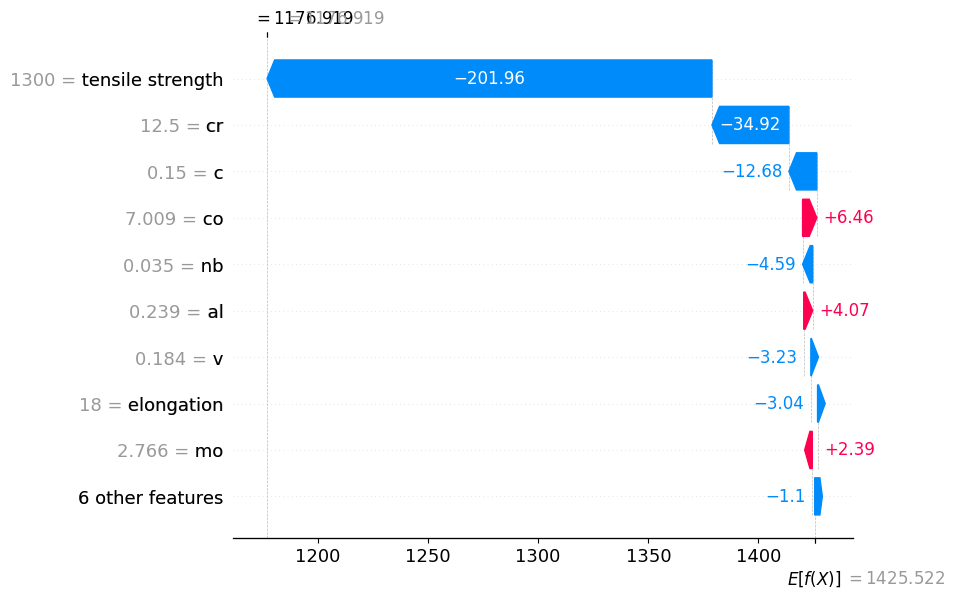

In [ ]:


def alloy_expert_system(alloy_dict):

    full_data = X.mean().to_dict()
    full_data.update(alloy_dict)
    test_df = pd.DataFrame([full_data])[X.columns]

    prediction = xgb_model.predict(test_df)[0]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values_single = explainer.shap_values(test_df)

    print(f"{'='*40}")
    print(f" (Yield Strength): {prediction:.2f} MPa")
    print(f"{'='*40}")

    shap.plots.waterfall(shap.Explanation(values=shap_values_single[0],
                                          base_values=explainer.expected_value,
                                          data=test_df.iloc[0],
                                          feature_names=X.columns.tolist()))

my_new_alloy = {
    'c': 0.15,
    'cr': 12.5,
    'ni': 8.0,
    'tensile strength': 1300,
    'elongation': 18
}

alloy_expert_system(my_new_alloy)

In [ ]:

joblib.dump(model, 'alloy_model.pkl')


['alloy_model.pkl']